# Load Necessary Tools
Vizualization References
[Pandas](http://pandas.pydata.org/pandas-docs/stable/visualization.html),
[Seaborn](https://seaborn.pydata.org/)

In [7]:
# Ensure Cuda is in Path
# !echo $PATH

# Import Helper Libraries
import data_utils
# Reload Tweaked/Edited Helper Libraries 
import importlib
importlib.reload(data_utils)

#from helper_libs.data_utils import *
#from helper_libs.model_utilities import *
#from helper_libs.churn_io import *

# Initialize Run Tracker
RUN=1
# Data Sci 
import pandas as pd
import numpy as np
from sklearn import metrics # roc_curve, roc_auc_score, auc, average_precision_score
from scipy.stats import boxcox
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.decomposition import PCA


# ML
import tensorflow as tf
from tensorflow.contrib import keras
Sequential = keras.models.Sequential
Dense = keras.layers.Dense
Dropout = keras.layers.Dropout
Activation = keras.layers.Activation
GaussianNoise = keras.layers.GaussianNoise
BatchNormalization = keras.layers.BatchNormalization


# OS
from subprocess import call

# Viz
%matplotlib inline
import matplotlib
matplotlib.style.use('ggplot')
from matplotlib import pyplot as plt
from pandas.tools.plotting import scatter_matrix
import time
#import datetime

# Import Data, Define Additional Vars

In [14]:
x_train, y_train, x_valid, y_valid, x_test, y_test = data_utils.get_data(
    tr=None, 
    bins=0, 
    threshold=2,
    fnorm='fn11',
    from_redshift=False)

Retrieving saved query data.
Not Transforming!


In [15]:
x_train.columns

Index(['vod_v1', 'vod_v2', 'vod_acc', 'nxt_v1', 'nxt_v2', 'nxt_acc',
       'as_on_dt', 'cust_guid', 'domestic', 'num_vol_losses',
       'pmt_pct_days_paid', 'num_pmts', 'pct_ppv1', 'ppv1_completer',
       'num_invol_fail', 'vod_lst_30days', 'vod_lst_30to60days',
       'vod_lst_60to90days', 'nxt_view_ep_lst_90days',
       'nxt_view_ep_lst_30days', 'nxt_lst_30to60days', 'nxt_lst_60to90days',
       'no_view_30days_flag', 'no_view_60days_flag', 'no_view_90days_flag',
       'num_strms_vshp_all', 'vod_num_strms', 'num_nc_em_rcvd_1st_60days',
       'overall_num_device_types', 'num_strms_vshp_net_orig',
       'num_strms_vshp_ring', 'rumble30', 'slam30', 'survivor30', 'mania30',
       'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct',
       'nov', 'dec', 'fortnight01', 'fortnight02', 'fortnight03',
       'fortnight04', 'fortnight05', 'fortnight06', 'fortnight07',
       'fortnight08', 'fortnight09', 'fortnight10', 'fortnight11',
       'fortnight12', 'fortnight13'

In [16]:
x_train.describe()

,vod_v1,vod_v2,vod_acc,nxt_v1,nxt_v2,nxt_acc,domestic,num_vol_losses,pmt_pct_days_paid,num_pmts,...,fortnight20,fortnight21,fortnight22,fortnight23,fortnight24,fortnight25,fortnight26,avg_rebuf_ratio_lst_30days,avg_rebuf_ratio_lst_60days,avg_rebuf_ratio_lst_90days
count,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,...,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000,711604.000000
mean,0.084848,-0.156420,-0.241268,-0.070913,-0.054190,0.016723,0.567712,0.106830,12.738495,13.404802,...,-0.851243,-0.975826,-0.903865,-0.953022,-0.906173,-0.953131,-0.906664,0.013729,0.015064,0.015786
std,3.658469,3.864045,6.040984,1.905751,1.788502,3.133177,0.823228,0.417495,8.022672,8.105663,...,0.524772,0.218547,0.427818,0.302902,0.422908,0.302557,0.421853,0.051876,0.050939,0.050691
min,-30.000000,-30.000000,-52.000000,-135.000000,-133.000000,-261.000000,-1.000000,0.000000,0.019441,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000
25%,-1.000000,-1.000000,-2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.000000,6.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000100,0.001000,0.001500
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,12.000000,13.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.002700,0.004200,0.004900
75%,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,0.000000,18.966071,20.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.009700,0.011700,0.012600
max,28.000000,28.000000,51.000000,130.000000,109.000000,135.000000,1.000000,23.000000,43.346728,45.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999900,0.998400,0.999400


In [ ]:
#==============================================
# Choose x_cols
#==============================================
#features = varnames('exl5','vod_pos','nxt_pos','months')
features = varnames('exl4','vod_pos','nxt_pos','months')
#features = exl5 + vod_pos + nxt_pos + b4
#features = varnames('exl5','vod30','vod3060','nxt30','nxt3060','months','b4')

xx_train = x_train.loc[:, features].values
xx_valid = x_valid.loc[:, features].values
xx_test  = x_test.loc[:,  features].values
if str(type(y_train)) != "<class 'numpy.ndarray'>":
    y_train = y_train.values
    y_valid = y_valid.values
    y_test = y_test.values


# Data Shape
n_train = xx_train.shape[0]
n_valid = xx_valid.shape[0]
n_test  = xx_test.shape[0]
n_data_tot = n_train + n_valid + n_test
n_data_train = xx_train.shape[0]
n_features = xx_train.shape[1]
n_classes  = y_train.shape[1]
    

print('Chosen Inputs: ', x_train.loc[:, features].columns, '\n')
print('Event: ', 'CHURN')  # y_cols deleted at one pont...
print('Num Classes: ', n_classes)
print('X Shape: ', xx_train.shape)


In [18]:
#-----------------------------------------------------
# Close TF Session
#-----------------------------------------------------
#sess.close()

# fpr, tpr, threshold = metrics.roc_curve(y_valid, y_pred, pos_label=1)
# auc = metrics.auc(fpr,tpr)
keras = True
y_set = 'Valid'  # 'valid' or 'test'

if keras!=True:
    saver.restore(sess, "./logs/model.ckpt")
    print("Model restored from ./log.")
    with tf.Session() as sess:
        y_pred = np.nan_to_num(sess.run(y_model, feed_dict = {x_feed: xx_valid}))
            
else:
    print("Keras!")
    y_pred_train = model.predict(xx_train)
    y_pred_valid = model.predict(xx_valid)
    #y_pred_test = model.predict(xx_test)
        


Keras!


In [45]:
thresh = 0.5   
    
y_class_train = np.array(y_pred_train > thresh, dtype=np.float32)     
#y_class_valid = np.array(y_pred_valid > thresh, dtype=np.float32) 
#y_class_test = np.array(y_pred_test > thresh, dtype=np.float32) 
    
print('|           | Training | Validation |')
print(
    '| RO-AUC    | ',
    round(100*metrics.roc_auc_score(y_train, y_pred_train),1), ' | ',
    #round(100*metrics.roc_auc_score(y_valid, y_pred_valid),1), ' | '
)
    
# Precision: 
#  -- precision is the ability of the classifier not to label a negative sample as positive
#  -- precision = tp / (tp+fp)
print(
    '| Precision | ',
    round(100*metrics.precision_score(y_train, y_class_train),1), ' | ',
    #round(100*metrics.precision_score(y_valid, y_class_valid),1), ' | '
)

# Recall: 
#  -- recall is the ability of the classifier to find all the positive samples
print(
    '| Recall    | ', 
    round(100*metrics.recall_score(y_train, y_class_train),1), ' | ',
    #round(100*metrics.recall_score(y_valid, y_class_valid),1), ' | '
)

# Average Precision: Area under the Precision-Recall curve
#  -- precision = tp / (tp+fp)
#  -- recall = tp / (tp+fn)
print(
    '| PR-AUC    | ',
    round(100*metrics.average_precision_score(y_train, y_pred_train),1), ' | ',
    #round(100*metrics.average_precision_score(y_valid, y_pred_valid),1), ' | '
)

# F1 Score
#  -- must binarize y_pred (e.g., what threshold is roc_auc_score using?)
#  -- f1 = harmonic_mean(precision, recall) = 2pr/(p+r)
#  -- y_class = ...
print(
    '| F1 Score  | ',
    round(100*metrics.f1_score(y_train, y_class_train),1), ' | ',
    #round(100*metrics.f1_score(y_valid, y_class_valid),1), ' | '
)

#print('| Accuracy  | ',round(100*metrics.accuracy_score(y_actual, y_class, normalize=True),1), ' | ')
#print('| R2 Score  | ', round(100*metrics.r2_score(y_actual, y_pred),1), ' | ')
#print('| MnAbsErr  | ', round(100*metrics.mean_absolute_error(y_actual, y_pred),1), ' | ')
#print('| MnSqErr   | ', round(100*metrics.mean_squared_error(y_actual, y_pred),1), ' | ')
#print('| MedAbsErr | ', round(100*metrics.median_absolute_error(y_actual, y_pred),1), ' | ')

|           | Training | Validation |
| RO-AUC    |  75.4  | 
| Precision |  59.1  | 
| Recall    |  10.6  | 
| PR-AUC    |  26.8  | 
| F1 Score  |  18.0  | 


## Gain plots

* [lift charts](http://www2.cs.uregina.ca/~dbd/cs831/notes/lift_chart/lift_chart.html)
* [MSFT explanation](https://docs.microsoft.com/en-us/sql/analysis-services/data-mining/lift-chart-analysis-services-data-mining)


1.  Order (y_pred, churn=y_valid (or y_test)) by y_pred
2.  Break into deciles 
3.  For each decile:
    - record exact population size
    - record number of churners
    - compute churn rate (churners/popSize)
    - compute % of all churners (theseChurners/allChurners)
    - compute cumaltive % of churners
    - show what cumalative % of churners would be if groups were randomly selected from general population

Can also record number of predicted churners...

In [31]:
# 0. Choose y_valid or y_test

# UPDATE: 2017-05-04:
#   -- new code means that we have to restore ckpt model data before this...
#   -- doing other stuff now / update this section later

#y_set = 'Valid'  # 'valid' or 'test'
#if y_set=='Valid': 
#    y_actual = y_valid
#    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_valid})
#else:
#    y_actual = y_test
#    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_test})#
y_actual = y_valid
y_pred = y_pred_valid


# 1. Order (y_pred, churn=y_valid (or y_test)) by y_pred
sortIndex      =  np.argsort(y_pred[:,0])
sortIndex      =  sortIndex[::-1]
y_pred_sorted  =  y_pred[sortIndex,0]
y_sorted       =  y_actual[sortIndex,0]

# 2. Break y_pred and churn arrays into deciles 
#    -- since arrays are same length, np.array_split() splits them
#       into same-sized groups (all equal if possible)
y_pred_deciles = np.array_split(y_pred_sorted, 10)
y_deciles      = np.array_split(y_sorted, 10)


# 3. Record decile properties 
# - Population size for each decile
decile = np.linspace(1,10,10)
decile_size = np.array([len(decile) 
                        for decile in y_pred_deciles])
# - Number of actual churners in each decile
num_churners = np.array([sum(decile) 
                         for decile in y_deciles])
# - Churn Rate (churners/popSize)
churn_rate = np.array([round(100*n_churn/decile_size[i],1)
                       for i,n_churn in enumerate(num_churners)])
# - Number of All Churners
all_churners = np.repeat(np.sum(num_churners), 10)
# - Decile's Churner Stock:  num_churners / all_churners
proportion_of_churn = np.array([round(100*n_churn/all_churners[0],2) 
                          for n_churn in num_churners])
# - Cumulative sum of Churner Stock
cum_prop = np.cumsum(proportion_of_churn)
# - Cumulative sum of Churner Stock if Deciles were randomized groups
cum_control = np.linspace(10,100,10)

# Generate Pandas DataFrame
churnTable = pd.DataFrame({
    'decile': decile,
    'size': decile_size,
    'num_churn': num_churners,
    'churn_rate': churn_rate,
    'all_churn': all_churners,
    'proportion_of_churn': proportion_of_churn,
    'cum_prop': cum_prop,
    'cum_control': cum_control
})
churnTable=churnTable[['decile','size','num_churn','churn_rate','all_churn','proportion_of_churn','cum_prop','cum_control']]

In [32]:
#plt.plot(y_pred[indices,0])
#fileName='name'
#churnTable.to_csv('Model-Data/'+fileName+'.csv')
churnTable

,decile,size,num_churn,churn_rate,all_churn,proportion_of_churn,cum_prop,cum_control
0,1.0,8895,2326,26.1,6379,36.46,36.46,10.0
1,2.0,8895,992,11.2,6379,15.55,52.01,20.0
2,3.0,8895,787,8.8,6379,12.34,64.35,30.0
3,4.0,8895,562,6.3,6379,8.81,73.16,40.0
4,5.0,8895,436,4.9,6379,6.83,79.99,50.0
5,6.0,8895,387,4.4,6379,6.07,86.06,60.0
6,7.0,8895,331,3.7,6379,5.19,91.25,70.0
7,8.0,8895,236,2.7,6379,3.70,94.95,80.0
8,9.0,8895,189,2.1,6379,2.96,97.91,90.0
9,10.0,8895,133,1.5,6379,2.08,99.99,100.0


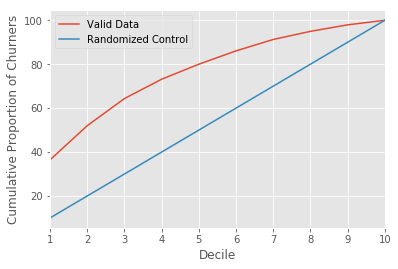

In [33]:
#plt.plot(churnTable['cum_stock'])
#plt.plot(churnTable['cum_stock_control'])
#churnTable['cum_prop'].plot()
#churnTable['cum_control'].plot()
fig = churnTable.plot(x='decile',y=['cum_prop','cum_control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
fig.legend(labels=[y_set+' Data', 'Randomized Control'])

In [ ]:
from matplotlib

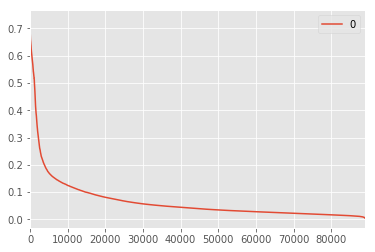

In [38]:
pd.DataFrame(y_pred_sorted).plot()

In [41]:
len(y_pred_sorted[(y_pred_sorted > 0.5) & (y_pred_sorted <= 0.6)])

675